# TP2 — Algoritmos Genéticos: aproximación de imágenes con triángulos

**SIA — ITBA**

Motor de AG que aproxima una imagen objetivo mediante `K` triángulos de color uniforme
sobre un canvas blanco.

## Orden de ejecución

Las celdas **1 a 12** definen el motor: hay que correrlas en orden una sola vez
(o volver a correr sólo la que se edita).
Las celdas **13 en adelante** son la ejecución del experimento.

| Celdas | Contenido |
|---|---|
| 1–2 | Setup e imports |
| 3–5 | Renderizado, métricas de fitness, inicialización |
| 6 | Clase `AG_Mejorado` (constructor) |
| 7 | **Métodos de selección** (los 7 del enunciado) |
| 8 | Supervivencia (aditiva / exclusiva) |
| 9 | Genotipo ↔ fenotipo y evaluación |
| 10 | **Cruza** |
| 11 | **Mutación** |
| 12 | Hill-climbing y bucle principal `run()` |
| 13+ | Ejecución, refinamiento y visualización |


## 1. Setup

Dependencias: `numpy pillow matplotlib scipy scikit-image`.
Si falta alguna, descomentar:


In [133]:
#!pip install -q pillow numpy matplotlib scipy scikit-image


## 2. Imports


In [134]:
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.metrics import structural_similarity as ssim
#import cupy as cp #optimizacion
import random
import copy
import time
import warnings
warnings.filterwarnings('ignore')


## 3. Renderizado

Convierte una lista de triángulos `(coords_normalizadas, color_rgba)` en una imagen PIL.
Las coordenadas y los colores viven en `[0,1]`, así que el mismo genoma se puede
renderizar a cualquier resolución.


In [135]:
def renderizar(triangulos, size=(100,100), fondo=(255,255,255,255)):
    """Renderiza los triángulos en una imagen del tamaño dado (sin antialiasing)."""
    img = Image.new('RGBA', size, fondo)
    draw = ImageDraw.Draw(img, 'RGBA')
    for pts, color in triangulos:
        x1,y1,x2,y2,x3,y3 = pts
        w,h = size
        p = [(int(x1*w), int(y1*h)),
             (int(x2*w), int(y2*h)),
             (int(x3*w), int(y3*h))]
        r,g,b,a = [int(c*255) for c in color]
        draw.polygon(p, fill=(r,g,b,a))
    return img

def renderizar_alta_resolucion(triangulos, size, supersample=2):
    """
    Renderiza con antialiasing mediante supersampling.
    - Dibuja a size * supersample y reduce con LANCZOS.
    """
    if supersample <= 1:
        return renderizar(triangulos, size)
    big_size = (size[0]*supersample, size[1]*supersample)
    big_img = renderizar(triangulos, big_size)
    # Reducir con LANCZOS (antialiasing de alta calidad)
    return big_img.resize(size, Image.LANCZOS)


## 4. Métricas y función de fitness

`fitness_combinado` es el **error** a minimizar: MSE de color + término de bordes (Sobel)
+ término de SSIM, con pesos configurables.


In [136]:
def mse(im1, im2):
    a1 = np.array(im1.convert('RGB')).astype(np.float32)/255.0
    a2 = np.array(im2.convert('RGB')).astype(np.float32)/255.0
    return np.mean((a1-a2)**2)

def gradiente(im):
    sx = ndimage.sobel(im, axis=0)
    sy = ndimage.sobel(im, axis=1)
    return np.hypot(sx, sy)

def fitness_combinado(im_orig, im_rec, peso_bordes=0.15, peso_ssim=0.15):
    err_color = mse(im_orig, im_rec)

    gray_orig = np.array(im_orig.convert('L')).astype(np.float32)/255.0
    gray_rec = np.array(im_rec.convert('L')).astype(np.float32)/255.0

    g_orig = gradiente(gray_orig)
    g_rec = gradiente(gray_rec)
    # misma escala para ambas: normalizar cada una por su propio máximo las
    # vuelve incomparables (un render plano quedaría "igual" que el original)
    escala = g_orig.max() + 1e-8
    err_bordes = np.mean(((g_orig - g_rec) / escala)**2)

    try:
        err_ssim = 1.0 - ssim(gray_orig, gray_rec, data_range=1.0, win_size=7)
    except ValueError:
        err_ssim = 1.0   # si falla, penalizar; con 0.0 el fallo BAJABA el error

    return err_color + peso_bordes * err_bordes + peso_ssim * err_ssim


## 5. Inicialización estructurada

En vez de arrancar de triángulos aleatorios, se genera una grilla donde cada triángulo
toma el color real de la imagen objetivo en el centro de su celda.
"Inicialización heurística". Dado que en totalmente random, tendrian igualdad de fitness y no puede haber selección.


In [137]:
def generar_triangulos_grilla(n, target, perturbacion=0.12):
    """
    Genera n triángulos distribuidos en grilla.
    Cada triángulo cubre la mayor parte de su celda (se solapan ligeramente).
    El color se toma del centro de la celda en la imagen objetivo.
    """
    w, h = target.size
    img = np.array(target.convert('RGB')).astype(np.float32) / 255.0

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    triangulos = []

    for i in range(rows):
        for j in range(cols):
            if len(triangulos) >= n:
                break

            cx = (j + 0.5) / cols
            cy = (i + 0.5) / rows
            cell_w = 1.0 / cols
            cell_h = 1.0 / rows

            # Vértices con perturbación, pero cubriendo casi toda la celda
            # Usamos 0.45 para que el triángulo ocupe ~90% del ancho/alto
            x1 = cx - cell_w*0.45 + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y1 = cy - cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)
            x2 = cx + cell_w*0.45 + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y2 = cy - cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)
            x3 = cx + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y3 = cy + cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)

            pts = [np.clip(x1,0,1), np.clip(y1,0,1),
                   np.clip(x2,0,1), np.clip(y2,0,1),
                   np.clip(x3,0,1), np.clip(y3,0,1)]

            # Color tomado de la imagen en el centro de la celda
            px = min(int(cx * w), w-1)
            py = min(int(cy * h), h-1)
            color = img[py, px].tolist() + [1.0]  # alfa fijo = 1 (opaco)

            triangulos.append((pts, color))

    # Completar con aleatorios si faltan
    while len(triangulos) < n:
        pts = list(np.random.uniform(0,1,6))
        color = list(np.random.uniform(0,1,3)) + [1.0]
        triangulos.append((pts, color))

    return triangulos[:n]

## 6. Clase `AG_Mejorado` — constructor

Las celdas 7 a 12 **agregan métodos a esta clase** con el decorador `add_method`.
Eso permite editar y re-ejecutar un grupo de operadores solo (por ejemplo, arreglar
`sel_ranking`) sin volver a correr toda la definición de la clase.

> Si re-ejecutás esta celda, tenés que volver a correr las celdas 7–12,
> porque la clase se redefine desde cero.


In [138]:
def add_method(cls):
    """Decorador: engancha la función como método de `cls`.

    Permite partir una clase grande en varias celdas del notebook y re-ejecutar
    sólo el grupo de métodos que se está modificando.
    """
    def deco(func):
        setattr(cls, func.__name__, func)
        return func
    return deco


class AG_Mejorado:
    def __init__(self, target, ntri, pop=50, gens=200, pm=0.20, pc=0.80,
                 elite=5, stop_error=0.001, modo_supervivencia='exclusiva',
                 paciencia=25, eval_size=64, seed=None,
                 torneo_size=None, torneo_prob=None):
        """
        target: imagen objetivo (PIL Image)
        ntri: número de triángulos (K)
        pop: tamaño de la población
        gens: número máximo de generaciones
        pm: probabilidad de mutación por gen
        pc: probabilidad de cruza
        elite: número de individuos élite (se preservan intactos)
        modo_supervivencia: 'aditiva' o 'exclusiva'
        paciencia: generaciones sin mejora para detener
        eval_size: resolución fija de evaluación
        seed: semilla; siembra los DOS generadores (random y np.random)
        """
        self.seed = seed
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.target = target
        self.K = ntri
        self.N = pop
        self.G = gens
        self.pm = pm
        self.pc = pc
        self.elite = elite
        self.stop_error = stop_error
        self.paciencia = paciencia
        self.w, self.h = target.size
        self.L = ntri * 10
        self.pop = []
        self.fits = []
        self.best_fit = float('inf')
        self.best_ind = None
        self.hist = []
        self.mejor_cada = []
        self.diversidad = []

        # Evaluación a resolución fija
        self.eval_size = eval_size
        self.current_eval_size = eval_size
        self.target_small_cache = {}  # caché de imágenes redimensionadas

        # Modos de selección y supervivencia
        self.modo_supervivencia = modo_supervivencia
        self.metodo_seleccion = 'torneo_det'
        self.tournament_size = torneo_size if torneo_size is not None else 3
        self.tournament_prob = torneo_prob if torneo_prob is not None else 0.75
        self.boltzmann_temp_min = 0.1
        self.boltzmann_temp_0 = 1.0

        self.n_random = 2 # inyección de aleatorios


## 7. Métodos de selección

Los 7 métodos que pide el enunciado: élite, ruleta, universal, Boltzmann, ranking
y torneos (determinístico y probabilístico).

`seleccionar()` es el despachador; `set_seleccion()` configura método e hiperparámetros.


In [139]:
@add_method(AG_Mejorado)
def seleccionar(self, k):
    if self.metodo_seleccion == 'elite':
        return self.sel_elite(k)
    elif self.metodo_seleccion == 'ruleta':
        return self.sel_ruleta(k)
    elif self.metodo_seleccion == 'universal':
        return self.sel_universal(k)
    elif self.metodo_seleccion == 'boltzmann':
        return self.sel_boltzmann(k)
    elif self.metodo_seleccion == 'ranking':
        return self.sel_ranking(k)
    elif self.metodo_seleccion == 'torneo_det':
        return self.sel_torneo_det(k)
    elif self.metodo_seleccion == 'torneo_prob':
        return self.sel_torneo_prob(k)
    else:
        raise ValueError("Método de selección no reconocido")


@add_method(AG_Mejorado)
def set_seleccion(self, metodo, **kwargs):
    self.metodo_seleccion = metodo
    if metodo == 'torneo_det':
        self.tournament_size = kwargs.get('t_size', 3)
    elif metodo == 'torneo_prob':
        self.tournament_size = kwargs.get('t_size', 2)
        self.tournament_prob = kwargs.get('t_prob', 0.8)
    elif metodo == 'boltzmann':
        self.boltzmann_temp_0 = kwargs.get('temp', 1.0)
        self.boltzmann_temp_min = kwargs.get('temp_min', 0.1)


### 7.1 Élite y ranking


In [140]:
@add_method(AG_Mejorado)
def sel_elite(self, k):
    idx = np.argsort(self.fits)[:k]
    return [self.pop[i] for i in idx]


@add_method(AG_Mejorado)
def sel_ranking(self, k, presion=1.5):
    sorted_idx = np.argsort(self.fits)
    N = len(self.pop)
    if N == 1: return [self.pop[0]] * k
    s = presion
    ranks = np.arange(N, 0, -1)              # ranks[0] = N  → el mejor
    probs = (2 - s)/N + 2*(ranks - 1)*(s - 1)/(N*(N - 1))
    probs = probs / probs.sum()
    elegidos_idx = np.random.choice(sorted_idx, size=k, p=probs)
    return [self.pop[i] for i in elegidos_idx]


### 7.2 Proporcionales al fitness: ruleta, universal (SUS) y Boltzmann


In [141]:
@add_method(AG_Mejorado)
def _aptitudes(self):
    """Error -> aptitud normalizada a la ventana de la población."""
    err = np.array(self.fits)
    apt = (err.max() - err) / (err.max() - err.min() + 1e-12) + 0.05
    return apt / apt.sum()


@add_method(AG_Mejorado)
def sel_ruleta(self, k):
    probs = self._aptitudes()
    return [self.pop[i] for i in np.random.choice(len(self.pop), k, p=probs)]


@add_method(AG_Mejorado)
def sel_universal(self, k):
    cum = np.cumsum(self._aptitudes())
    punteros = np.random.rand()/k + np.arange(k)/k
    idx = np.clip(np.searchsorted(cum, punteros), 0, len(self.pop)-1)
    return [self.pop[i] for i in idx]


@add_method(AG_Mejorado)
def sel_boltzmann(self, k):
    T = max(self.boltzmann_temp_min,
            self.boltzmann_temp_0 * (1.0 - getattr(self, 'gen_actual', 0) / self.G))
    fits = np.array(self.fits)
    exp_vals = np.exp(-(fits - fits.min()) / T)
    probs = exp_vals / exp_vals.sum()
    return [self.pop[i] for i in np.random.choice(len(self.pop), k, p=probs)]


### 7.3 Torneos (determinístico y probabilístico)


In [142]:
@add_method(AG_Mejorado)
def sel_torneo_det(self, k):
    t = min(self.tournament_size, len(self.pop))
    elegidos = []
    for _ in range(k):
        idx = np.random.choice(len(self.pop), t, replace=False)
        elegidos.append(self.pop[idx[np.argmin([self.fits[i] for i in idx])]])
    return elegidos


@add_method(AG_Mejorado)
def sel_torneo_prob(self, k):
    t = min(self.tournament_size, len(self.pop))
    elegidos = []
    for _ in range(k):
        idx = sorted(np.random.choice(len(self.pop), t, replace=False),
                     key=lambda i: self.fits[i])
        for pos, cand in enumerate(idx):   # p, p(1-p), p(1-p)^2, ...
            if pos == len(idx) - 1 or np.random.rand() < self.tournament_prob:
                elegidos.append(self.pop[cand])
                break
    return elegidos


## 8. Estrategias de supervivencia

`aditiva` (fill-all) y `exclusiva` (fill-parent).


In [143]:
@add_method(AG_Mejorado)
def sobrevivir(self, padres, hijos):
    """Devuelve (nueva_pop, sus_fitness) para no tener que re-evaluarla después."""
    fits_hijos = [self.eval_ind(h) for h in hijos]

    if self.modo_supervivencia == 'aditiva':          # fill-all: población + hijos
        pool = self.pop + hijos
        fits = self.fits + fits_hijos                 # reusa el fitness de los padres
        idx = np.argsort(fits)[:self.N]
        return [pool[i] for i in idx], [fits[i] for i in idx]

    elif self.modo_supervivencia == 'exclusiva':      # fill-parent
        idx_ord = np.argsort(fits_hijos)
        if len(hijos) >= self.N:
            sel = idx_ord[:self.N]
            return [hijos[i] for i in sel], [fits_hijos[i] for i in sel]

        ids_hijos = {id(h) for h in hijos}
        comp, comp_f = [], []
        for i in np.argsort(self.fits):
            if id(self.pop[i]) not in ids_hijos and len(comp) < self.N - len(hijos):
                comp.append(self.pop[i])
                comp_f.append(self.fits[i])
        pop = [hijos[i] for i in idx_ord] + comp
        fits = [fits_hijos[i] for i in idx_ord] + comp_f
        return pop[:self.N], fits[:self.N]
    else:
        raise ValueError("Modo de supervivencia no reconocido (use 'aditiva' o 'exclusiva')")


## 9. Genotipo ↔ fenotipo y evaluación

Un individuo es un vector plano de `K*10` genes: por triángulo, 6 coordenadas + 4 canales RGBA.


In [144]:
@add_method(AG_Mejorado)
def genes_a_triangulos(self, genes):
    out = []
    for i in range(self.K):
        start = i*10
        coords = genes[start:start+6].tolist()
        color = genes[start+6:start+10].tolist()
        out.append((coords, color))
    return out


@add_method(AG_Mejorado)
def triangulos_a_genes(self, triangulos):
    genes = []
    for pts, color in triangulos:
        genes.extend(pts)
        genes.extend(color)
    return np.array(genes)

### 9.1 Inicialización de la población


In [145]:
@add_method(AG_Mejorado)
def init_pop_estructurada(self):
    self.pop = []                       # (19) no acumular población entre corridas
    for _ in range(self.N):
        # (20) una grilla propia por individuo -> diversidad estructural real
        tri = generar_triangulos_grilla(self.K, self.target, perturbacion=0.12)
        ind = self.triangulos_a_genes(tri)
        self.pop.append(np.clip(ind + np.random.normal(0, 0.05, self.L), 0, 1))
    self.eval_pop()


### 9.2 Evaluación (con resolución progresiva)


In [146]:
@add_method(AG_Mejorado)
def get_target_resized(self, size):
    """Devuelve la imagen objetivo redimensionada al tamaño dado (con caché)."""
    key = size
    if key not in self.target_small_cache:
        self.target_small_cache[key] = self.target.resize((size, size), Image.LANCZOS)
    return self.target_small_cache[key]


@add_method(AG_Mejorado)
def eval_ind(self, genes, size=None):
    """Evalúa un individuo a la resolución dada (si None, usa self.current_eval_size)."""
    if size is None:
        size = self.current_eval_size
    tri = self.genes_a_triangulos(genes)
    target_small = self.get_target_resized(size)
    rendered = renderizar(tri, size=(size, size))
    err = fitness_combinado(target_small, rendered)
    return err


@add_method(AG_Mejorado)
def eval_pop(self):
    self.fits = []
    for ind in self.pop:
        e = self.eval_ind(ind)
        self.fits.append(e)
    idx = np.argmin(self.fits)
    if self.fits[idx] < self.best_fit:
        self.best_fit = self.fits[idx]
        self.best_ind = copy.deepcopy(self.pop[idx])


@add_method(AG_Mejorado)
def actualizar_best(self):
    """Actualiza best_ind/best_fit desde self.fits, sin recalcular nada."""
    idx = int(np.argmin(self.fits))
    if self.fits[idx] < self.best_fit:
        self.best_fit = self.fits[idx]
        self.best_ind = copy.deepcopy(self.pop[idx])


## 10. Operadores de cruza

Cruza por bloques completos de triángulos (10 genes cada uno).


In [147]:
@add_method(AG_Mejorado)
def cx_triangular(self, a, b):
    """Crossover por bloques completos de triángulos (10 genes cada uno)."""
    c1 = a.copy()
    c2 = b.copy()

    n_bloques = np.random.randint(1, max(2, self.K // 4))
    indices = np.random.choice(self.K, n_bloques, replace=False)

    for t in indices:
        start = t * 10
        end = start + 10
        c1[start:end] = b[start:end]
        c2[start:end] = a[start:end]

    return c1, c2


## 11. Operadores de mutación

Mutación multigen con sigma decreciente, más mutaciones dirigidas a vértices y a color.


In [148]:
@add_method(AG_Mejorado)
def mut_multigen_adaptativo(self, ind, gen, maxgenes=12):
    """Mutación de múltiples genes con sigma decreciente."""
    sigma = 0.15 * (1.0 - gen/self.G) + 0.02
    if np.random.rand() < self.pm:
        n = np.random.randint(1, maxgenes+1)
        idxs = np.random.choice(self.L, n, replace=False)
        for idx in idxs:
            delta = np.random.normal(0, sigma)
            ind[idx] = np.clip(ind[idx] + delta, 0, 1)
    return ind


@add_method(AG_Mejorado)
def mutar_vertices_adaptativo(self, ind, gen):
    """Mutación específica de coordenadas de un triángulo."""
    sigma = 0.10 * (1.0 - gen/self.G) + 0.01
    if np.random.rand() < self.pm * 0.5:
        t_idx = np.random.randint(0, self.K)
        start = t_idx * 10
        for i in range(6):
            idx = start + i
            delta = np.random.normal(0, sigma)
            ind[idx] = np.clip(ind[idx] + delta, 0, 1)
    return ind


@add_method(AG_Mejorado)
def mutar_color_adaptativo(self, ind, gen):
    """Mutación específica de colores de un triángulo."""
    sigma = 0.10 * (1.0 - gen/self.G) + 0.01
    if np.random.rand() < self.pm * 0.5:
        t_idx = np.random.randint(0, self.K)
        start = t_idx * 10 + 6
        for i in range(3):
            idx = start + i
            delta = np.random.normal(0, sigma)
            ind[idx] = np.clip(ind[idx] + delta, 0, 1)
    return ind


## 12. Refinamiento local y bucle principal


In [149]:
@add_method(AG_Mejorado)
def hill_climbing(self, individuo, iteraciones=2, paso_inicial=0.05, size_eval=None):
    """
    Refinamiento local: perturba cada gen y acepta si mejora.
    size_eval por defecto = la resolución de evaluación del AG, para que el
    error resultante sea comparable con el de run().
    """
    if size_eval is None:
        size_eval = self.eval_size

    mejor = individuo.copy()
    mejor_err = self.eval_ind(mejor, size=size_eval)

    for _ in range(iteraciones):
        orden = np.random.permutation(self.L)
        for idx in orden:
            for signo in [-1, 1]:
                candidato = mejor.copy()
                delta = np.random.uniform(0, paso_inicial) * signo
                candidato[idx] = np.clip(candidato[idx] + delta, 0, 1)
                err_cand = self.eval_ind(candidato, size=size_eval)
                if err_cand < mejor_err:
                    mejor = candidato
                    mejor_err = err_cand
                    break
        paso_inicial *= 0.5

    return mejor, mejor_err


### 12.1 `run()` — bucle evolutivo


In [150]:
@add_method(AG_Mejorado)
def run(self):
    self.init_pop_estructurada()
    self.hist = []
    self.mejor_cada = []
    self.diversidad = []
    t0 = time.time()

    sin_mejora = 0
    ultimo_mejor = self.best_fit

    for gen in range(self.G):
        self.gen_actual = gen

        # 1. Selección de padres
        num_padres = self.N - self.elite
        if num_padres % 2 != 0:
            num_padres += 1
        padres = self.seleccionar(num_padres)

        # 2. Generación de hijos
        hijos = []
        while len(hijos) < self.N - self.elite - self.n_random:
            p1, p2 = random.sample(padres, 2)
            if np.random.rand() < self.pc:
                c1, c2 = self.cx_triangular(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()

            c1 = self.mut_multigen_adaptativo(c1, gen)
            c2 = self.mut_multigen_adaptativo(c2, gen)
            c1 = self.mutar_vertices_adaptativo(c1, gen)
            c2 = self.mutar_vertices_adaptativo(c2, gen)
            c1 = self.mutar_color_adaptativo(c1, gen)
            c2 = self.mutar_color_adaptativo(c2, gen)

            hijos.append(c1)
            if len(hijos) < self.N - self.elite - self.n_random:
                hijos.append(c2)

        # 3. Inyección de individuos aleatorios (diversidad)
        for _ in range(self.n_random):
            hijos.append(np.random.uniform(0, 1, self.L))

        # 4. Elitismo real + supervivencia
        orden = np.argsort(self.fits)[:self.elite]
        elites = [self.pop[i].copy() for i in orden]
        elites_fit = [self.fits[i] for i in orden]

        resto, resto_fit = self.sobrevivir(padres, hijos)
        self.pop = elites + resto[:self.N - self.elite]
        self.fits = elites_fit + resto_fit[:self.N - self.elite]
        self.actualizar_best()

        # 5. Registro
        self.hist.append(self.best_fit)
        self.diversidad.append(len({i.tobytes() for i in self.pop}))
        if gen % 10 == 0:
            self.mejor_cada.append((gen, self.best_fit, copy.deepcopy(self.best_ind)))

        # 6. Criterios de parada
        if self.best_fit < self.stop_error:
            print(f"¡Error mínimo alcanzado en generación {gen}!")
            break

        if self.best_fit < ultimo_mejor - 1e-6:
            ultimo_mejor = self.best_fit
            sin_mejora = 0
        else:
            sin_mejora += 1

        if sin_mejora >= self.paciencia:
            print(f"Estancamiento detectado en generación {gen} (sin mejora durante {self.paciencia} gens)")
            break

    print(f"Tiempo total: {time.time()-t0:.1f} s")
    return self.best_ind, self.best_fit, self.hist, self.mejor_cada


---
# Ejecución

## 13. Carga de la imagen objetivo


prueba.jpg.jpeg: (1024, 1024) -> (120, 120)


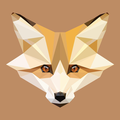

In [151]:
from pathlib import Path

CARPETA = Path("imagenesprueba")
TARGET_SIZE = 120

IMG_PATH = sorted(CARPETA.glob("*"))[0]
img_original = Image.open(IMG_PATH).convert('RGB')
target = img_original.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)

print(f"{IMG_PATH.name}: {img_original.size} -> {target.size}")
display(target)


## 14. Hiperparámetros


In [152]:
# Parámetros (ajustables)
K = 500              # Número de triángulos
N = 50               # Tamaño de población
G = 5000              # Generaciones
PM = 0.20            # Prob. de mutación (aumentada)
PC = 0.80            # Prob. de cruza
ELITE = 5            # Número de élites
STOP_ERROR = 0.001
PACiencia = 500
EVAL_SIZE = 64       # Resolución de evaluación (fija)
SEED = 42            # None = no reproducible


## 15. Correr el algoritmo genético


In [153]:
print("\n--- EJECUTANDO ALGORITMO GENÉTICO MEJORADO ---")
ag = AG_Mejorado(target, K, pop=N, gens=G, pm=PM, pc=PC,
                 elite=ELITE, stop_error=STOP_ERROR,
                 modo_supervivencia='exclusiva',
                 paciencia=PACiencia,
                 eval_size=EVAL_SIZE, seed=SEED)

# Selección: puedes cambiar a 'ranking', 'torneo_det', 'ruleta', etc.
ag.set_seleccion('ranking', presion=1.5)

best, err, hist, mejor_cada = ag.run()
print(f"Error final (eval_size={ag.eval_size}): {err:.6f}")



--- EJECUTANDO ALGORITMO GENÉTICO MEJORADO ---
Tiempo total: 804.1 s
Error final (eval_size=64): 0.020273


## 16. Refinamiento local (hill-climbing)


In [154]:
print("\n--- Refinando con Hill-Climbing ---")
best_refinado, err_refinado = ag.hill_climbing(best, iteraciones=2, paso_inicial=0.03,
                                               size_eval=ag.eval_size)
print(f"Error a eval_size={ag.eval_size}:  AG {err:.6f}  ->  +HC {err_refinado:.6f}  "
      f"({100*(err-err_refinado)/err:+.1f}%)")

# control a alta resolución: mismo par de individuos, misma escala
pre  = ag.eval_ind(best, size=100)
post = ag.eval_ind(best_refinado, size=100)
print(f"Error a size=100        :  AG {pre:.6f}  ->  +HC {post:.6f}  ({100*(pre-post)/pre:+.1f}%)")



--- Refinando con Hill-Climbing ---
Error a eval_size=64:  AG 0.020273  ->  +HC 0.017693  (+12.7%)
Error a size=100        :  AG 0.046679  ->  +HC 0.044577  (+4.5%)


## 17. Renderizado final en alta resolución


In [155]:
max_dim = 500
w_orig, h_orig = img_original.size
if max(w_orig, h_orig) > max_dim:
    factor = max_dim / max(w_orig, h_orig)
    final_size = (int(w_orig * factor), int(h_orig * factor))
else:
    final_size = (w_orig, h_orig)

print(f"Renderizando a {final_size[0]}x{final_size[1]} con antialiasing...")
tri_final = ag.genes_a_triangulos(best_refinado)
reconstructed_high = renderizar_alta_resolucion(tri_final, size=final_size, supersample=2)

# También renderizamos a la resolución de evolución para comparar
reconstructed_eval = renderizar(tri_final, size=(TARGET_SIZE, TARGET_SIZE))


Renderizando a 500x500 con antialiasing...


## 18. Visualización de resultados


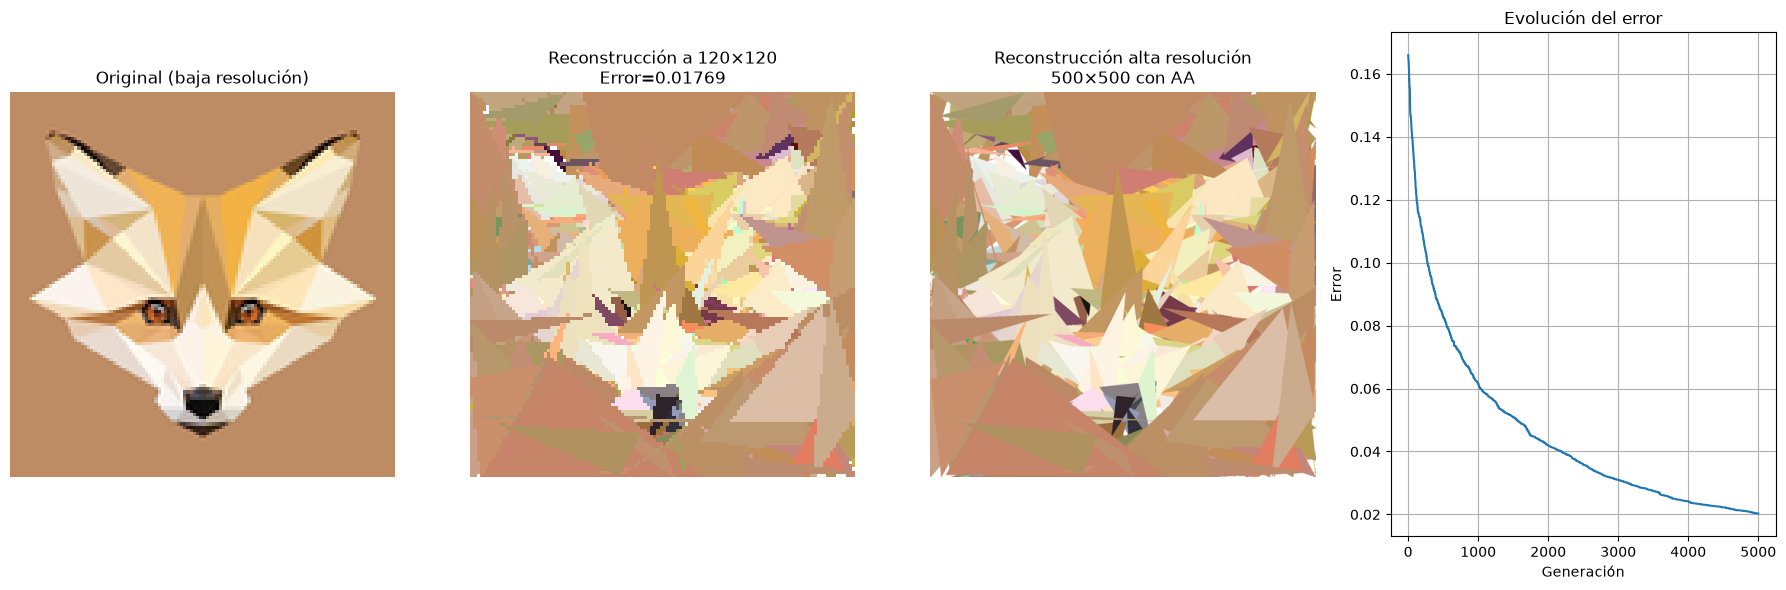

In [156]:
# --- VISUALIZACIÓN ---
plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.imshow(target)
plt.title("Original (baja resolución)")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(reconstructed_eval)
plt.title(f"Reconstrucción a {TARGET_SIZE}×{TARGET_SIZE}\nError={err_refinado:.5f}")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(reconstructed_high)
plt.title(f"Reconstrucción alta resolución\n{final_size[0]}×{final_size[1]} con AA")
plt.axis('off')

plt.subplot(1,4,4)
plt.plot(hist)
plt.title("Evolución del error")
plt.xlabel("Generación")
plt.ylabel("Error")
plt.grid(True)

plt.tight_layout()
plt.show()


## 19. Evolución a lo largo de las generaciones


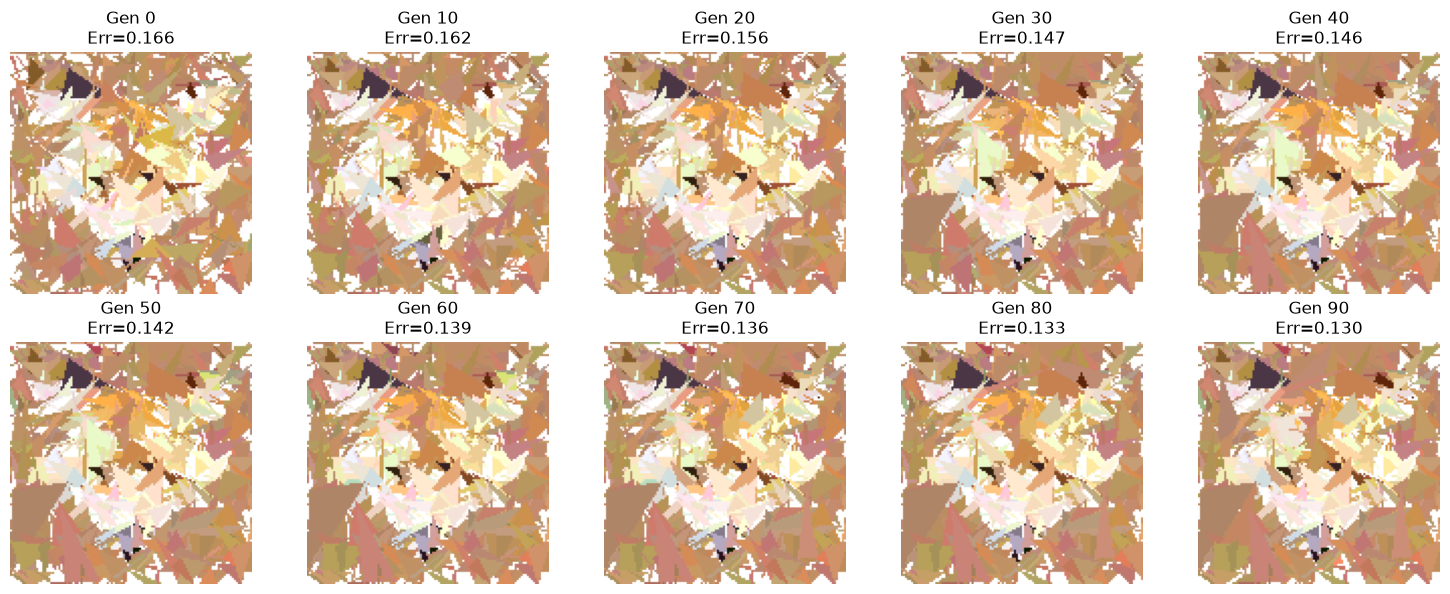

In [157]:
# --- Evolución intermedia ---
if len(mejor_cada) > 1:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, (gen, e, ind) in enumerate(mejor_cada[:10]):
        r, c = i//5, i%5
        tri_tmp = ag.genes_a_triangulos(ind)
        img_tmp = renderizar(tri_tmp, size=(TARGET_SIZE, TARGET_SIZE))
        axes[r, c].imshow(img_tmp)
        axes[r, c].set_title(f"Gen {gen}\nErr={e:.3f}")
        axes[r, c].axis('off')
    plt.tight_layout()
    plt.show()


## 20. Enumeración de triángulos y guardado


In [158]:
print("\n--- Triángulos finales (primeros 10) ---")
for i, (pts, col) in enumerate(tri_final[:10]):
    print(f"{i+1}: vértices=({pts[0]:.3f},{pts[1]:.3f}) ({pts[2]:.3f},{pts[3]:.3f}) ({pts[4]:.3f},{pts[5]:.3f})  color=({col[0]:.3f},{col[1]:.3f},{col[2]:.3f},{col[3]:.3f})")

print(f"\n... y {len(tri_final)-10} triángulos más.")

# Opcional: guardar la imagen final
reconstructed_high.save("reconstruccion_final.png")
print("\nImagen final guardada como 'reconstruccion_final.png'")



--- Triángulos finales (primeros 10) ---
1: vértices=(0.117,0.000) (0.064,0.436) (0.038,0.135)  color=(0.717,0.588,0.418,1.000)
2: vértices=(0.307,0.898) (0.398,0.391) (0.614,0.282)  color=(0.353,0.075,0.830,0.487)
3: vértices=(0.032,0.000) (0.104,0.023) (0.181,0.000)  color=(0.630,0.609,0.477,0.977)
4: vértices=(0.034,0.071) (0.000,0.041) (0.048,0.135)  color=(0.710,0.664,0.625,1.000)
5: vértices=(0.129,0.152) (0.233,0.130) (0.213,0.000)  color=(0.618,0.652,0.439,0.914)
6: vértices=(0.174,0.000) (0.191,0.118) (0.140,0.093)  color=(0.784,0.539,0.333,1.000)
7: vértices=(0.218,0.031) (0.286,0.017) (0.330,0.056)  color=(0.684,0.569,0.308,0.803)
8: vértices=(0.372,0.018) (0.361,0.000) (0.384,0.127)  color=(0.830,0.591,0.370,0.923)
9: vértices=(0.402,0.019) (0.371,0.000) (0.344,0.000)  color=(0.779,0.585,0.431,1.000)
10: vértices=(0.311,0.000) (0.606,0.057) (0.502,0.152)  color=(0.656,0.611,0.341,1.000)

... y 490 triángulos más.

Imagen final guardada como 'reconstruccion_final.png'
